# Clasificación de Productos mediante Machine Learning

## Autor: Agustín Pluda

## Descripción

Este proyecto utiliza como punto de partida el dataset curado de productos obtenido a partir del conjunto de datos Online Retail II. El dataset contiene información histórica de productos y transacciones, incluyendo la descripción de cada producto, pero no dispone de categorías comerciales.

El objetivo es desarrollar un modelo de Machine Learning capaz de clasificar automáticamente los productos en diferentes categorías utilizando principalmente la información contenida en sus descripciones.

Este notebook cubre todo el pipeline de clasificación: construcción del catálogo, clustering exploratorio, definición de la taxonomía, etiquetado por reglas, set gold, entrenamiento del modelo y su aplicación al catálogo completo. El resultado final es `data/processed/products_categorized.csv`.

El análisis del comportamiento de las ventas según categoría se desarrolla en un notebook aparte, `product_sales_analysis.ipynb`, que parte de los resultados generados acá. Finalmente, esos resultados serán utilizados para desarrollar un dashboard interactivo en Power BI.

## 0. Importación de librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
%matplotlib inline

## 1. Preparación de los datos

### 1.1. Carga del dataset curado de productos

In [2]:
df = pd.read_csv("data/main/online_retail_sales.csv")

df.head()

,invoice,stock_code,description,quantity,invoice_datetime,unit_price,customer_id,country,invoice_date,invoice_time,canceled,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,07:45:00,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,07:45:00,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,07:45:00,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,07:45:00,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,07:45:00,False,30.0


### 1.2. Exploración Inicial

In [3]:
df.shape

(1003417, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1003417 entries, 0 to 1003416
Data columns (total 12 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   invoice           1003417 non-null  int64  
 1   stock_code        1003417 non-null  str    
 2   description       1003417 non-null  str    
 3   quantity          1003417 non-null  int64  
 4   invoice_datetime  1003417 non-null  str    
 5   unit_price        1003417 non-null  float64
 6   customer_id       776579 non-null   float64
 7   country           1003417 non-null  str    
 8   invoice_date      1003417 non-null  str    
 9   invoice_time      1003417 non-null  str    
 10  canceled          1003417 non-null  bool   
 11  total_price       1003417 non-null  float64
dtypes: bool(1), float64(3), int64(2), str(6)
memory usage: 85.2 MB


In [5]:
df.describe(include="all")

,invoice,stock_code,description,quantity,invoice_datetime,unit_price,customer_id,country,invoice_date,invoice_time,canceled,total_price
count,1.003417e+06,1003417,1003417,1.003417e+06,1003417,1.003417e+06,776579.000000,1003417,1003417,1003417,1003417,1.003417e+06
unique,NaN,4902,5384,NaN,36736,NaN,NaN,43,604,775,1,NaN
top,NaN,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom,2011-12-05,14:41:00,False,NaN
freq,NaN,5511,5601,NaN,1113,NaN,NaN,923646,5242,3662,1003417,NaN
mean,5.376840e+05,NaN,NaN,1.115002e+01,NaN,3.341597e+00,15326.605714,NaN,NaN,NaN,NaN,1.957872e+01
std,2.694308e+04,NaN,NaN,1.287341e+02,NaN,4.758682e+00,1692.864496,NaN,NaN,NaN,NaN,1.999757e+02
min,4.894340e+05,NaN,NaN,1.000000e+00,NaN,3.000000e-02,12346.000000,NaN,NaN,NaN,NaN,6.000000e-02
25%,5.148070e+05,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13979.000000,NaN,NaN,NaN,NaN,4.130000e+00
50%,5.381160e+05,NaN,NaN,4.000000e+00,NaN,2.100000e+00,15253.000000,NaN,NaN,NaN,NaN,1.008000e+01
75%,5.616250e+05,NaN,NaN,1.200000e+01,NaN,4.130000e+00,16795.000000,NaN,NaN,NaN,NaN,1.770000e+01


### 1.3 Revisión Especifica en `description`

In [6]:
df["description"].head(20)

0     15CM CHRISTMAS GLASS BALL 20 LIGHTS
1                      PINK CHERRY LIGHTS
2                     WHITE CHERRY LIGHTS
3            RECORD FRAME 7" SINGLE SIZE 
4          STRAWBERRY CERAMIC TRINKET BOX
5              PINK DOUGHNUT TRINKET POT 
6                     SAVE THE PLANET MUG
7      FANCY FONT HOME SWEET HOME DOORMAT
8                               CAT BOWL 
9          DOG BOWL , CHASING BALL DESIGN
10           HEART MEASURING SPOONS LARGE
11     LUNCHBOX WITH CUTLERY FAIRY CAKES 
12                  DOOR MAT BLACK FLOCK 
13               LOVE BUILDING BLOCK WORD
14               HOME BUILDING BLOCK WORD
15          ASSORTED COLOUR BIRD ORNAMENT
16             PEACE WOODEN BLOCK LETTERS
17           CHRISTMAS CRAFT WHITE FAIRY 
18              HEART IVORY TRELLIS LARGE
19              HEART FILIGREE DOVE LARGE
Name: description, dtype: str

In [7]:
print(f"Cantidad de valores unicos: {df["description"].nunique()}")
print(f"Cantidad de nulos: {df["description"].isna().sum()}")

Cantidad de valores unicos: 5384
Cantidad de nulos: 0


In [8]:
df["description"].value_counts().head(20)

description
WHITE HANGING HEART T-LIGHT HOLDER    5601
REGENCY CAKESTAND 3 TIER              3950
JUMBO BAG RED RETROSPOT               3312
ASSORTED COLOUR BIRD ORNAMENT         2848
PARTY BUNTING                         2705
LUNCH BAG  BLACK SKULL.               2402
STRAWBERRY CERAMIC TRINKET BOX        2352
JUMBO STORAGE BAG SUKI                2352
JUMBO SHOPPER VINTAGE RED PAISLEY     2209
HEART OF WICKER SMALL                 2195
60 TEATIME FAIRY CAKE CASES           2179
LUNCH BAG SPACEBOY DESIGN             2128
LUNCH BAG CARS BLUE                   2091
HOME BUILDING BLOCK WORD              2087
WOODEN FRAME ANTIQUE WHITE            2087
PAPER CHAIN KIT 50'S CHRISTMAS        2068
NATURAL SLATE HEART CHALKBOARD        2059
WOODEN PICTURE FRAME WHITE FINISH     2026
PACK OF 60 PINK PAISLEY CAKE CASES    2025
REX CASH+CARRY JUMBO SHOPPER          1996
Name: count, dtype: int64

### 1.4 Extraer columnas de interes

In [9]:
df_products = df[["stock_code", "description"]].drop_duplicates()
df_products.shape

(5613, 2)

In [10]:
df_products.head(20)

,stock_code,description
0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS
1,79323P,PINK CHERRY LIGHTS
2,79323W,WHITE CHERRY LIGHTS
3,22041,"RECORD FRAME 7"" SINGLE SIZE"
4,21232,STRAWBERRY CERAMIC TRINKET BOX
5,22064,PINK DOUGHNUT TRINKET POT
6,21871,SAVE THE PLANET MUG
7,21523,FANCY FONT HOME SWEET HOME DOORMAT
8,22350,CAT BOWL
9,22349,"DOG BOWL , CHASING BALL DESIGN"


In [11]:
df_products["description"].value_counts().head(20)

description
METAL SIGN,CUPCAKE SINGLE HOOK         6
COLOURING PENCILS BROWN TUBE           3
WHITE BAMBOO RIBS LAMPSHADE            3
DOOR MAT BLACK FLOCK                   2
SMALL MARSHMALLOWS PINK BOWL           2
BISCUITS SMALL BOWL LIGHT BLUE         2
HANGING HEART ZINC T-LIGHT HOLDER      2
CHARLIE+LOLA RED HOT WATER BOTTLE      2
CHARLIE LOLA BLUE HOT WATER BOTTLE     2
CHARLIE + LOLA BISCUITS TINS           2
CHARLIE AND LOLA FIGURES TINS          2
BLACK/BLUE DOTS RUFFLED UMBRELLA       2
RED/WHITE DOTS RUFFLED UMBRELLA        2
SET/3 RUSSIAN DOLL STACKING TINS       2
WHITE HANGING HEART T-LIGHT HOLDER     2
VINYL RECORD FRAME SILVER              2
WOODEN FRAME ANTIQUE WHITE             2
PINK 3 PIECE MINI DOTS CUTLERY SET     2
BLUE 3 PIECE MINI DOTS CUTLERY SET     2
TEA TIME PARTY BUNTING                 2
Name: count, dtype: int64

### 1.5 Exploración de palabras

In [12]:
words = df_products["description"].str.split().explode()
words.value_counts().head(60)

description
PINK          455
SET           427
BLUE          347
OF            318
RED           293
HEART         292
VINTAGE       282
GLASS         214
BAG           212
WHITE         207
CHRISTMAS     200
BOX           181
ROSE          181
DESIGN        177
CANDLE        176
FLOWER        171
BLACK         159
SMALL         157
METAL         156
GREEN         154
3             151
LARGE         144
HOLDER        142
HANGING       133
CAKE          133
DECORATION    132
SILVER        128
WALL          118
RETROSPOT     115
PAPER         114
IN            112
WITH          111
T-LIGHT       110
NECKLACE      106
4             106
AND            98
MUG            96
COVER          96
MINI           91
FAIRY          90
CANDLES        89
BOWL           88
IVORY          88
CARD           87
POLKADOT       86
GARDEN         85
CUSHION        83
ART            83
TEA            81
WRAP           81
TREE           80
ASSORTED       78
SPOT           78
6              75
SPOTTY         7

**Observación:** En la descripción podemos encontrar varias caracteristicas o adjetivos de los productos, como colores, materias, tamaños, estilo o relleno generico (como "SET" o "DESIGN"). Esto nos indica que tenemos que tener en cuenta estas palabras para posteriormente asignarlas como stop-words para la clasificación.

## 2. Construcción del catálogo de productos

### 2.1 Diagnóstico

In [13]:
pares = df[["stock_code", "description"]].drop_duplicates()

print(f"Pares (stock_code, description) unicos : {len(pares)}")
print(f"stock_code unicos: {pares['stock_code'].nunique()}")
print(f"description unicas: {pares['description'].nunique()}")

desc_por_codigo = pares.groupby("stock_code")["description"].nunique()
print(f"\nstock_code con mas de una description: {(desc_por_codigo > 1).sum()}")

ejemplo = desc_por_codigo.idxmax()
print(f"\nEjemplo -- stock_code {ejemplo}:")
for d in pares.loc[pares["stock_code"] == ejemplo, "description"]:
    print(f"   {d}")

Pares (stock_code, description) unicos : 5613
stock_code unicos: 4902
description unicas: 5384

stock_code con mas de una description: 646

Ejemplo -- stock_code 20685:
   RED SPOTTY COIR DOORMAT
   DOOR MAT RED SPOT
   DOORMAT RED SPOT
   DOORMAT RED RETROSPOT


### 2.2 Normalización

In [14]:
df["stock_code"] = df["stock_code"].str.strip().str.upper()

# Todo lo que no sea letra o numero pasa a ser un separador.
# Resuelve de una sola vez: espacios sobrantes y dobles, comillas ("7\" SINGLE"),
# comas pegadas (TEA,COFFEE), barras (SET/3) y simbolos (CHARLIE+LOLA).
df["description_clean"] = (
    df["description"]
      .str.upper()
      .str.replace(r"[^A-Z0-9]+", " ", regex=True)
      .str.strip()
)

### 2.3 Descripción Canónica

In [15]:
frecuencias = (
    df.groupby(["stock_code", "description_clean"])
      .size()
      .reset_index(name="n_filas")
)
frecuencias["largo"] = frecuencias["description_clean"].str.len()

# Desempate: si dos variantes empatan en frecuencia, gana la mas larga
# (suele ser la completa, no la truncada).
canonicas = (
    frecuencias
      .sort_values(["stock_code", "n_filas", "largo"], ascending=[True, False, False])
      .drop_duplicates(subset="stock_code", keep="first")
      [["stock_code", "description_clean"]]
)


### 2.4 Metricas de negocio

In [16]:
metricas = df.groupby("stock_code").agg(
    n_transacciones=("invoice", "count"),
    unidades_totales=("quantity", "sum"),
    revenue_total=("total_price", "sum"),
    precio_medio=("unit_price", "mean"),
).reset_index()

catalogo = canonicas.merge(metricas, on="stock_code")
catalogo[["revenue_total", "precio_medio"]] = catalogo[["revenue_total", "precio_medio"]].round(2)


### 2.5 Separaración de Vouchers

In [17]:
es_voucher = catalogo["stock_code"].str.startswith("GIFT_")
vouchers = catalogo[es_voucher].copy()
catalogo = catalogo[~es_voucher].reset_index(drop=True)

print(f"Vouchers separados: {len(vouchers)}")
vouchers


Vouchers separados: 7


,stock_code,description_clean,n_transacciones,unidades_totales,revenue_total,precio_medio
4723,GIFT_0001_10,DOTCOMGIFTSHOP GIFT VOUCHER 10 00,14,15,126.21,8.42
4724,GIFT_0001_20,DOTCOMGIFTSHOP GIFT VOUCHER 20 00,26,28,471.06,16.81
4725,GIFT_0001_30,DOTCOMGIFTSHOP GIFT VOUCHER 30 00,24,24,610.09,25.42
4726,GIFT_0001_40,DOTCOMGIFTSHOP GIFT VOUCHER 40 00,5,5,166.09,33.22
4727,GIFT_0001_50,DOTCOMGIFTSHOP GIFT VOUCHER 50 00,6,6,253.59,42.26
4728,GIFT_0001_70,DOTCOMGIFTSHOP GIFT VOUCHER 70 00,1,1,59.57,59.57
4729,GIFT_0001_80,DOTCOMGIFTSHOP GIFT VOUCHER 80 00,1,1,69.56,69.56


**Nota:** En el dataset habia un tipo de descripción que se decidio dejar, se trataban de los productos "GIFT_..." que son los vouchers. En este proyecto no vienen al caso, por lo tanto se excluyen. 

### 2.6 Verificación

In [18]:
print(f"Productos en el catalogo : {len(catalogo)}")
print(f"stock_code es unico      : {catalogo['stock_code'].is_unique}")
print(f"Revenue catalogo         : {catalogo['revenue_total'].sum():,.2f}")
print(f"Revenue vouchers         : {vouchers['revenue_total'].sum():,.2f}")
print(f"Revenue dataset completo : {df['total_price'].sum():,.2f}")


Productos en el catalogo : 4724
stock_code es unico      : True
Revenue catalogo         : 19,643,861.62
Revenue vouchers         : 1,756.17
Revenue dataset completo : 19,645,617.79


### 2.7 QA manual de las 646 fusiones

In [19]:
variantes = df.groupby("stock_code")["description"].unique()
conflictivos = variantes[variantes.apply(len) > 1]

for cod in conflictivos.index[:8]:
    elegida = catalogo.loc[catalogo["stock_code"] == cod, "description_clean"].squeeze()
    print(f"{cod}")
    for v in conflictivos[cod]:
        print(f"   variante : {v}")
    print(f"   ELEGIDA  : {elegida}\n")


15058A
   variante : BLUE WHITE SPOTS GARDEN PARASOL
   variante : BLUE POLKADOT GARDEN PARASOL
   ELEGIDA  : BLUE POLKADOT GARDEN PARASOL

15058B
   variante : PINK WHITE SPOTS GARDEN PARASOL
   variante : PINK POLKADOT GARDEN PARASOL
   ELEGIDA  : PINK POLKADOT GARDEN PARASOL

16011
   variante :  ANIMAL STICKERS
   variante : ANIMAL STICKERS
   ELEGIDA  : ANIMAL STICKERS

16012
   variante : FOOD/DRINK SPUNGE STICKERS
   variante : FOOD/DRINK SPONGE STICKERS
   ELEGIDA  : FOOD DRINK SPONGE STICKERS

16151A
   variante : FLOWER DES BLUE HANDBAG/ORANG HANDL
   variante : FLOWERS HANDBAG blue and orange
   ELEGIDA  : FLOWERS HANDBAG BLUE AND ORANGE

16156L
   variante : WRAP, CAROUSEL
   variante : WRAP CAROUSEL
   ELEGIDA  : WRAP CAROUSEL

16161U
   variante : WRAP,SUKI AND FRIENDS
   variante : WRAP SUKI AND FRIENDS
   ELEGIDA  : WRAP SUKI AND FRIENDS

17107D
   variante : FLOWER FAIRY,5 SUMMER B'DRAW LINERS
   variante : FLOWER FAIRY 5 DRAWER LINERS
   variante : FLOWER FAIRY 5 SUMM

**Caso 17107D:** la heurística eligió FLOWER FAIRY 5 SUMMER B DRAW LINERS, que en realidad es la variante más rota de las tres (viene de B'DRAW), no la más prolija (FLOWER FAIRY 5 DRAWER LINERS existe y es mejor texto). Esto pasa porque el criterio es "más frecuente en transacciones", no "mejor redactada" — son cosas distintas y a veces el dato sucio es el que más se vendió. No es un bug, es una limitación conocida del método.

### 2.8 Guardar Catalogo

In [20]:
catalogo.to_csv("data/processed/products_catalog.csv", index=False)

## 3. Cluster Exploratorio

### 3.1 Vectorizar

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

modificadores = {
    # colores
    "red", "blue", "pink", "green", "black", "white", "cream", "ivory",
    "silver", "gold", "golden", "yellow", "purple", "orange", "brown",
    "grey", "gray", "navy", "lilac",
    # materiales
    "glass", "metal", "wooden", "wood", "ceramic", "fabric", "acrylic",
    "tin", "paper", "plastic", "enamel", "zinc",
    # tamaños
    "small", "large", "mini", "jumbo", "giant", "big", "tiny",
    # estilo/patron (transversales a todo el catalogo, no distinguen producto)
    "vintage", "antique", "retro", "classic", "classical", "french",
    "victorian", "floral", "polkadot", "gingham", "spotty", "retrospot",
    # relleno generico
    "design", "assorted", "set", "pack", "asstd", "col", "colour",
}

stop_words_extendida = list(ENGLISH_STOP_WORDS.union(modificadores))

vectorizer = TfidfVectorizer(
    stop_words=stop_words_extendida,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.5,
)

X = vectorizer.fit_transform(catalogo["description_clean"])
print(f"Matriz TF-IDF: {X.shape}")


Matriz TF-IDF: (4724, 2918)


- max_df=0.5 descarta términos que aparecen en más de la mitad de los productos (ruido tipo "SET", "DESIGN"). 

- min_df=2 descarta términos que aparecen una sola vez (no generalizan).

### 3.2 Identificar el K óptimo

#### 3.2.1 Metodo del codo (Elbow Method)

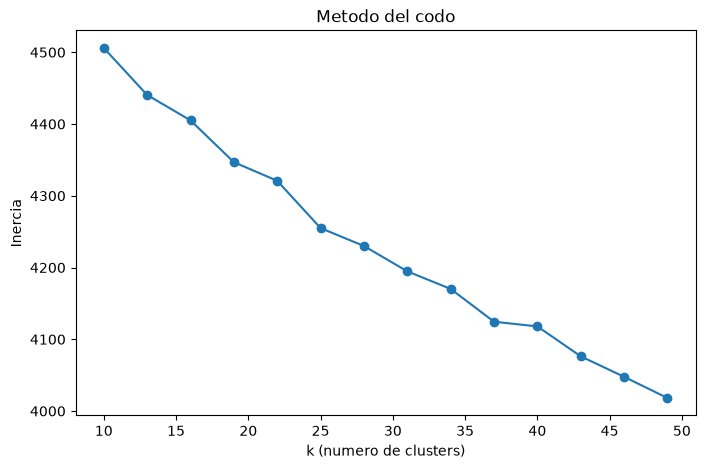

In [22]:
from sklearn.cluster import KMeans

inercias = []
rango_k = range(10, 50, 3)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(rango_k), inercias, marker="o")
plt.xlabel("k (numero de clusters)")
plt.ylabel("Inercia")
plt.title("Metodo del codo")
plt.show()


#### 3.2.2 Metodo Silhouette Score

k=10  silhouette=0.0140 (diff=-0.0140)


k=13  silhouette=0.0228 (diff=-0.0088)


k=16  silhouette=0.0251 (diff=-0.0023)


k=19  silhouette=0.0289 (diff=-0.0038)


k=22  silhouette=0.0327 (diff=-0.0037)


...

k=37  silhouette=0.0501 (diff=-0.0047)


k=40  silhouette=0.0492 (diff=0.0009)


k=43  silhouette=0.0515 (diff=-0.0023)


k=46  silhouette=0.0547 (diff=-0.0032)


k=49  silhouette=0.0582 (diff=-0.0035)


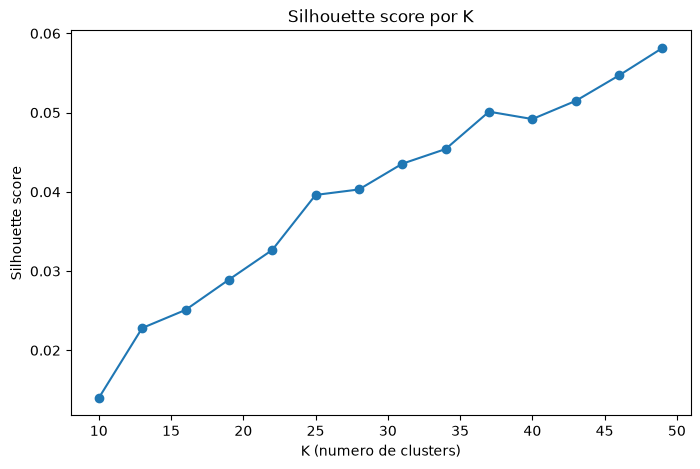

In [23]:
from sklearn.metrics import silhouette_score

rango_k = range(10, 50, 3)
silhouettes = []
anterior = 0

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=2000, random_state=42)
    silhouettes.append(score)
    print(f"k={k:2d}  silhouette={score:.4f} (diff={(anterior-score):.4f})")
    anterior = score

plt.figure(figsize=(8, 5))
plt.plot(list(rango_k), silhouettes, marker="o")
plt.xlabel("K (numero de clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score por K")
plt.show()


### 3.3 Entrenamiento con K

In [24]:
K = 45
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
catalogo["cluster"] = kmeans.fit_predict(X)

conteo = catalogo["cluster"].value_counts().sort_values(ascending=False)

print(conteo.head(10))
print(f"\nCluster mas grande: {conteo.iloc[0]} productos ({conteo.iloc[0]/len(catalogo)*100:.1f}% del catalogo)")

cluster
22    1864
4      137
6      135
39     132
35     125
0      123
36     117
20     106
1      101
32      88
Name: count, dtype: int64

Cluster mas grande: 1864 productos (39.5% del catalogo)


### 3.4 Inspeccionar cada cluster


In [25]:
terminos = vectorizer.get_feature_names_out()

for c in range(K):
    centro = kmeans.cluster_centers_[c]
    top_idx = centro.argsort()[::-1][:12]
    top_terminos = [terminos[i] for i in top_idx]

    ejemplos = catalogo.loc[catalogo["cluster"] == c, "description_clean"].sample(
        min(6, (catalogo["cluster"] == c).sum()), random_state=42
    )

    print(f"\n=== Cluster {c} (n={sum(catalogo['cluster'] == c)}) ===")
    print("Terminos:", ", ".join(top_terminos))
    print("Ejemplos:")
    for e in ejemplos:
        print(f"   - {e}")


=== Cluster 0 (n=123) ===
Terminos: christmas, tree, christmas tree, star, 60cm, tree 60cm, card, ribbons, christmas star, christmas craft, 50 christmas, stocking
Ejemplos:
   - CHRISTMAS HANGING STAR WITH BELL
   - CHRISTMAS GINGHAM TREE
   - CHRISTMAS MUSICAL ZINC TREE
   - BLACKCHRISTMAS TREE 30CM
   - BIRD BOX CHRISTMAS TREE DECORATION
   - WOODEN STAR CHRISTMAS SCANDINAVIAN

=== Cluster 1 (n=101) ===
Terminos: decoration, heart decoration, heart, hanging, hanging decoration, christmas decoration, christmas, tree decoration, tree, bird, star, easter decoration
Ejemplos:
   - CANDY HEART HANGING DECORATION
   - HEART DECORATION PAINTED ZINC
   - JINGLE BELL HEART DECORATION
   - HEART WREATH DECORATION WITH BELL
   - DECORATION WOBBLY RABBIT METAL
   - EASTER DECORATION NATURAL CHICK

=== Cluster 2 (n=33) ===
Terminos: water, hot, water bottle, hot water, bottle, lola hot, charlie lola, charlie, lola, heart hot, knitted, skull hot
Ejemplos:
   - CHARLIE LOLA RED HOT WATER BOTTLE
  

**Observación:** En este punto, realize un proceso iterativo (desde 3.1 hasta 3.4) de prueba de cantidad de clusters, modificando el valor de K desde 15 hasta 45, analizando como se formaban los diferentes clusters con sus terminos tops, con los cuales fui identificando stop-words que, con el paso de las iteraciones, fui agregando a una lista extendida stop-words.

Con el fin de las iteraciones, pude identificar que habia un cluster con un gran cumulo de los datos. Este cluster se itero de esta forma:
- 2776 (K=20, 58.8%), 
- 2299 (K=35, 48.7%),
- 1864 (K=45, 39.5%)

Con lo cual, pasado hasta cierto punto, era cada vez más dificil distribuir/diversificar el cluster más grande porque conllevaba aumentar mucho más K, que terminaria siendo un desproposito por la cantidad de divisiones que tendriamos del conjunto completo.

## 4. Definición de la taxonomía

A partir de los términos y ejemplos revelados por el clustering exploratorio (K=20, 35 y 45),
se definieron 17 categorías comerciales mutuamente excluyentes. La categoría `Otros` se reserva
para productos que genuinamente no encajan en ninguna — debe ser la excepción, no el destino
por defecto: si supera el 15% del catálogo, es señal de que falta una categoría.

> **Nota:** la taxonomía original tenía 15 categorías. Al revisar los 27 productos que el
> etiquetado manual dejó en `Otros` aparecieron dos grupos nítidos — artículos de escritura y
> juguetes — que se promovieron a categorías propias (`Escritura y Útiles`, `Juguetes y Juegos`).
> `Otros` nunca puede aprender el modelo porque las reglas jamás la devuelven, así que cada
> producto mal encasillado ahí era un error garantizado.

La tabla sigue el **orden temático** del clustering original, no el orden de prioridad de las
reglas (`ORDEN_PRIORIDAD`, celda de 5.1): cuando una descripción matchea varias categorías, gana
la que aparece primero en `ORDEN_PRIORIDAD`, no la que aparece primero aquí.

| # | Categoría | Definición | Ejemplos |
|---|---|---|---|
| 1 | **Navidad** | Adornos, luces y accesorios de temporada navideña | CHRISTMAS GINGHAM TREE, GLITTER CHRISTMAS STAR, SET 10 CARDS CHRISTMAS TREE |
| 2 | **Pascua y Fiestas** | Decoración de Pascua y artículos de fiesta (bunting, globos, invitaciones, bolsas de fiesta) | PINK BUNNY EASTER EGG BASKET, HAPPY EASTER HANGING DECORATION, WOODLAND PARTY BAG STICKER SET |
| 3 | **Velas e Iluminación** | Portavelas, velas y luces decorativas | ZINC HEART LATTICE T LIGHT HOLDER, COLUMBIAN CANDLE ROUND, SET 12 LAVENDER BOTANICAL T LIGHTS |
| 4 | **Joyería y Bijouterie** | Aros, pulseras, collares, dijes de bolso/celular | MIDNIGHT BLUE CRYSTAL DROP EARRINGS, MURANO STYLE GLASS BRACELET PINK, PINK BERTIE MOBILE PHONE CHARM |
| 5 | **Bolsos y Carteras** | Bolsos, mochilas y carteras de tela | JUMBO BAG STRAWBERRY, STRAWBERRY CHARLOTTE BAG, RED RETROSPOT PICNIC BAG |
| 6 | **Cocina y Mesa** | Vajilla, utensilios y accesorios de cocina/mesa | RED RETROSPOT BOWL, SET OF 2 TEA TOWELS APPLE AND PEARS, CAKE STAND VICTORIAN FILIGREE LARGE |
| 7 | **Decoración del Hogar** | Objetos decorativos generales (corazones, guirnaldas, adornos colgantes) | HANGING HEART MIRROR DECORATION, DECORATIVE WICKER HEART MEDIUM |
| 8 | **Espejos, Relojes y Arte de Pared** | Espejos, relojes y cuadros de pared | BLACK BAROQUE WALL CLOCK, FILIGREE WALL MIRROR ANTIQUE WHITE, DOT MATRIX CANVAS ART PICTURE |
| 9 | **Textiles del Hogar** | Fundas de cojín y textiles decorativos chicos | FRENCH PAISLEY CUSHION COVER, CROSS STITCH ALPHABET CUSHION COVER |
| 10 | **Papelería y Tarjetería** | Tarjetas de saludo, notebooks, papel de regalo, stickers e insumos de manualidades (cintas, doilies) | SKULLS GREETING CARD, LARGE PURPLE BABUSHKA NOTEBOOK, WRAP CAROUSEL |
| 11 | **Marcos y Fotografía** | Marcos y álbumes de fotos | WHITE GRAND BAROQUE PHOTO FRAME, PASTEL PINK PHOTO ALBUM |
| 12 | **Cajas y Almacenamiento** | Cajas de té/dinero/costura y perillas de cajón | SEWING BOX RETROSPOT DESIGN, TOADSTOOL MONEY BOX, DRAWER KNOB CRACKLE GLAZE IVORY |
| 13 | **Jardín y Exterior** | Artículos de jardín, exterior y entrada (incluye felpudos) | CERAMIC BIRDHOUSE FINCH BLUE LARGE, BLUE POLKADOT GARDEN PARASOL, DOORMAT RED RETROSPOT |
| 14 | **Carteles y Señalética** | Carteles metálicos decorativos | BATHROOM METAL SIGN, HOME SWEET HOME METAL SIGN |
| 15 | **Botellas de Agua Caliente y Confort** | Bolsas de agua caliente y calentadores de manos | CHARLIE LOLA RED HOT WATER BOTTLE, HAND WARMER RED LOVE HEART |
| 16 | **Juguetes y Juegos** | Juguetes, rompecabezas y juegos de mesa o de jardín | MINI JIGSAW SPACEBOY, WOODEN SKITTLES GARDEN SET, MINI PLAYING CARDS SPACEBOY |
| 17 | **Escritura y Útiles** | Útiles de escritura, dibujo y corrección | 36 PENCILS TUBE POSY, ASSORTED COLOUR JUMBO PEN, DAISY ERASERS IN BAG |

## 5. Etiquetas débiles por reglas

### 5.1 Diccionario de reglas

In [26]:
import re

REGLAS_CATEGORIAS = {
    # Estas dos categorias se agregaron para vaciar "Otros", que era la unica
    # etiqueta del gold que el modelo no podia predecir: entrena con las
    # etiquetas de las reglas, y las reglas nunca devuelven "Otros".
    # Van PRIMERO a proposito, porque el orden del dict es el orden de
    # prioridad: "MINI PLAYING CARDS SPACEBOY" es un juego antes que una
    # tarjeta, y "SET 12 COLOURING PENCILS DOILY" es escritura antes que
    # papeleria.
    "Juguetes y Juegos": [
        r"jigsaws?", r"puzzles?", r"playing cards", r"\bgames?\b", r"skittles",
        r"spinning tops?", r"yo.?yo", r"snakes? and ladders", r"dominoes",
        r"marbles", r"rocking horses?", r"\bdolls?\b", r"teddy|teddies",
        r"soldiers?", r"\btoys?\b", r"water bombs?", r"\bkites?\b",
        r"jack in the box",
    ],
    "Escritura y Útiles": [
        r"pencils?", r"\bpens?\b", r"sharpeners?", r"sharpner", r"crayons?",
        r"erasers?", r"\brubbers?\b", r"rulers?", r"\bchalk\b", r"colouring",
        r"\bpaints?\b",
    ],
    "Navidad": [
        r"christmas", r"xmas", r"santa", r"snowman", r"reindeer",
        r"holly", r"robin", r"stockings?", r"baubles?", r"advent",
        r"mistletoe", r"nativity",
    ],
    "Pascua y Fiestas": [
        # FIX: se saco r"birthdays?". Es un motivo impreso, no un tipo de
        # producto, y le robaba las tarjetas de cumpleaños a Papeleria y
        # Tarjeteria. Las guirnaldas de cumpleaños las sigue tomando buntings?.
        r"easter", r"bunn(y|ies)", r"buntings?",
        r"bal+oons?", r"party invites?", r"party bags?", r"invitations?",
    ],
    "Botellas de Agua Caliente y Confort": [
        r"hot water bottles?", r"hand warmers?", r"foot warmers?",
        r"hotties?",
    ],
    "Joyería y Bijouterie": [
        r"earrings?", r"bracelets?", r"necklaces?", r"pendants?",
        r"brooches?", r"bag charms?", r"phone charms?", r"key ?rings?",
        r"hoops?", r"jewell?ery",
    ],
    "Bolsos y Carteras": [
        r"\bbags?\b", r"handbags?", r"shoppers?", r"rucksacks?",
        r"backpacks?", r"purses?", r"totes?", r"wallets?",
    ],
    "Marcos y Fotografía": [
        r"photo frames?", r"picture frames?", r"photo albums?",
        r"photo shelf", r"\bframes?\b",
    ],
    "Espejos, Relojes y Arte de Pared": [
        r"mirrors?", r"\bclocks?\b", r"wall art", r"canvas",
    ],
    "Jardín y Exterior": [
        r"gardens?", r"birdhouses?", r"birdcages?", r"plant pots?",
        r"parasols?", r"watering cans?", r"trowels?", r"\brakes?\b",
        r"bird feeders?", r"secateurs",
        # FIX: antes caia en Textiles del Hogar por \bmats?\b. Un felpudo es un
        # articulo de entrada/exterior, no un textil decorativo. Jardin tiene
        # mayor prioridad que Textiles, asi que agregarlo aca alcanza.
        r"door ?mats?",
    ],
    "Cajas y Almacenamiento": [
        r"trinket box(es)?", r"money box(es)?", r"sewing box(es)?",
        r"gift box(es)?", r"jewellery box(es)?", r"keepsake box(es)?",
        r"storage box(es)?", r"treasure box(es)?", r"memory box(es)?",
        r"book box(es)?", r"lunch box(es)?", r"snack box(es)?",
        r"nesting box(es)?", r"trinket pots?", r"drawer knobs?",
        r"storage", r"cabinets?", r"chest of drawers", r"\bchests?\b",
        r"coat racks?", r"coat hangers?",
    ],
    "Cocina y Mesa": [
        r"\bmugs?\b", r"\bbowls?\b", r"\bplates?\b", r"\bcups?\b",
        r"teapots?", r"kettles?", r"cutlery", r"\bspoons?\b",
        r"\bforks?\b", r"\bknife\b", r"\bknives\b", r"cake ?stands?",
        r"cake ?tins?", r"cake ?cases?", r"tea ?sets?", r"tea towels?",
        r"teacups?", r"tea glass(es)?", r"saucers?", r"aprons?",
        r"coasters?", r"placemats?", r"napkins?", r"chopsticks?",
        r"popcorn", r"baking", r"\bjam\b", r"kitchen scales?",
        r"\bpantry\b", r"bread bins?", r"biscuit tins?",
        r"tea coffee sugar", r"\bjugs?\b",
    ],
    "Textiles del Hogar": [
        r"cushions?", r"curtains?", r"\brugs?\b", r"bedspreads?",
        r"quilts?", r"blankets?", r"\bmats?\b",   # FIX: doormats? -> Jardin
    ],
    "Papelería y Tarjetería": [
        # pencils/pens/colouring/paints migraron a "Escritura y Útiles"
        r"greeting cards?", r"\bcards?\b", r"notebooks?", r"journals?",
        r"gift wraps?", r"\bwraps?\b", r"stickers?", r"stationery",
        r"envelopes?", r"paper craft", r"paper chain", r"ribbons?",
        r"gift tags?", r"felt ?craft", r"doil(y|ies)",
    ],
    "Carteles y Señalética": [
        r"metal signs?", r"\bsigns?\b", r"plaques?",
    ],
    "Velas e Iluminación": [
        r"candles?", r"t ?lights?", r"votives?", r"lanterns?",
        r"\blights?\b",
    ],
    "Decoración del Hogar":[
        r"decorations?", r"ornaments?", r"garlands?", r"wreaths?",
        r"wicker", r"hanging hearts?", r"\bmobiles?\b", r"chalkboards?",
        r"black ?boards?", r"memo ?boards?", r"building blocks?",
        r"alphabet blocks?", r"\bfans?\b"
    ]
}

# Prioridad: Primera categoria que matchea.
ORDEN_PRIORIDAD = list(REGLAS_CATEGORIAS.keys())

print(f"Categorias en la taxonomia: {len(REGLAS_CATEGORIAS)}")
print(f"Patrones totales: {sum(len(v) for v in REGLAS_CATEGORIAS.values())}")


Categorias en la taxonomia: 17
Patrones totales: 187


### 5.2 Función de etiquetado

In [27]:
def etiquetar_por_reglas(texto, reglas, orden):
    texto = texto.lower()
    for categoria in orden:
        patron = "|".join(reglas[categoria])
        if re.search(patron, texto):
            return categoria
    return None

catalogo["categoria_regla"] = catalogo["description_clean"].apply(
    lambda t: etiquetar_por_reglas(t, REGLAS_CATEGORIAS, ORDEN_PRIORIDAD)
)

### 5.3 Cobertura

In [28]:
cobertura = catalogo["categoria_regla"].notna().mean()
print(f"Cobertura de las reglas: {cobertura:.1%}")

catalogo["categoria_regla"].value_counts(dropna=False)

Cobertura de las reglas: 68.6%


categoria_regla
NaN                                    1482
Cocina y Mesa                           509
Velas e Iluminación                     388
Joyería y Bijouterie                    347
Papelería y Tarjetería                  295
Navidad                                 238
Bolsos y Carteras                       204
Decoración del Hogar                    183
Espejos, Relojes y Arte de Pared        165
Cajas y Almacenamiento                  159
Jardín y Exterior                       151
Pascua y Fiestas                        117
Textiles del Hogar                      103
Juguetes y Juegos                        95
Escritura y Útiles                       94
Marcos y Fotografía                      82
Carteles y Señalética                    71
Botellas de Agua Caliente y Confort      41
Name: count, dtype: int64

### 5.4 Auditoría de conflictos

In [29]:
def categorias_que_matchean(texto, reglas):
    texto = texto.lower()
    return [cat for cat, patrones in reglas.items() if re.search("|".join(patrones), texto)]

catalogo["categorias_candidatas"] = catalogo["description_clean"].apply(
    lambda t: categorias_que_matchean(t, REGLAS_CATEGORIAS)
)
catalogo["num_categorias_candidatas"] = catalogo["categorias_candidatas"].apply(len)

catalogo["num_categorias_candidatas"].value_counts().sort_index()


num_categorias_candidatas
0    1482
1    2834
2     400
3       8
Name: count, dtype: int64

In [30]:
conflictos = catalogo[catalogo["num_categorias_candidatas"] > 1]
conflictos[["description_clean", "categorias_candidatas", "categoria_regla"]].sample(15, random_state=42)

,description_clean,categorias_candidatas,categoria_regla
1268,ROBIN CHRISTMAS CARD,"[Navidad, Papelería y Tarjetería]",Navidad
2520,ROLL WRAP 50 S RED CHRISTMAS,"[Navidad, Papelería y Tarjetería]",Navidad
2761,SET 10 CARDS XMAS GRAPHIC 17218,"[Navidad, Papelería y Tarjetería]",Navidad
739,MIRRORED WALL ART PHOTO FRAMES,"[Marcos y Fotografía, Espejos, Relojes y Arte ...",Marcos y Fotografía
1008,SILVER PLATE CANDLE BOWL SMALL,"[Cocina y Mesa, Velas e Iluminación]",Cocina y Mesa
1299,CHRISTMAS PUDDING TRINKET POT,"[Navidad, Cajas y Almacenamiento]",Navidad
1791,CARDHOLDER HOLLY WREATH METAL,"[Navidad, Decoración del Hogar]",Navidad
3334,LARGE CIRCULAR MIRROR MOBILE,"[Espejos, Relojes y Arte de Pared, Decoración ...","Espejos, Relojes y Arte de Pared"
2705,WRAP BIRD GARDEN,"[Jardín y Exterior, Papelería y Tarjetería]",Jardín y Exterior
2776,SET 10 CHRISTMAS CARDS HOHOHO 16956,"[Navidad, Papelería y Tarjetería]",Navidad


### 5.5 Productos sin etiqueta, priorizados por revenue

In [31]:
sin_etiqueta = catalogo[catalogo["categoria_regla"].isna()].sort_values(
    "revenue_total", ascending=False
)
sin_etiqueta[["stock_code", "description_clean", "revenue_total"]].head(30)

,stock_code,description_clean,revenue_total
1203,21915,RED HARMONICA IN BOX,42664.54
4021,85014B,RED RETROSPOT UMBRELLA,31268.00
269,20750,RED RETROSPOT MINI CASES,26866.63
1752,22551,PLASTERS IN TIN SPACEBOY,25912.87
525,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,25407.27
3480,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,24445.61
1754,22554,PLASTERS IN TIN WOODLAND ANIMALS,22853.72
1756,22556,PLASTERS IN TIN CIRCUS PARADE,22334.08
4020,85014A,BLACK BLUE POLKADOT UMBRELLA,22213.70
268,20749,ASSORTED COLOUR MINI CASES,22097.61


**Observación:** Hasta este punto, se realizo el etiquetado de productos por reglas. En 5.1 se asigaron las reglas categorias en un diccionario, con la prioridad de "primera categoria que matchea, se asigna esa". Posteriormente en 5.2 se aplica estas reglas sobre las descripciones.

Luego en el 5.3 se comprueba el porcentaje de cobertura por reglas, seguido por el 5.4 donde se auditan los conflictos entre categorias, y terminando con el 5.5 que muestran los productos sin etiquetar en el orden de ganancia total (revenue_total).

Con todo esto definido, se hizo un proceso de iteración donde en cada pasada, a traves de 5.4 y 5.5 se identificaban los "errores" o "faltas" que tenia el diccionario del reglas, y con esto progresivamente se pulian las reglas categoricas y por lo tanto, también el porcentaje de cobertura, llegando a un 68,6% de cobertura (incluyendo las dos categorias agregadas despues, Juguetes y Juegos y Escritura y Utiles), suficiente para pasar al siguiente proceso.

### 5.6 Armado de la Muestra Gold

In [32]:
N_POR_ESTRATO = 25

catalogo["estrato_muestreo"] = catalogo["categoria_regla"].fillna("Sin regla")

muestra_gold = (
    catalogo.groupby("estrato_muestreo", group_keys=False)
    .sample(n=N_POR_ESTRATO, random_state=42)
)

print(f"Tamano de la muestra: {len(muestra_gold)}")
muestra_gold["estrato_muestreo"].value_counts()


Tamano de la muestra: 450


estrato_muestreo
Bolsos y Carteras                      25
Botellas de Agua Caliente y Confort    25
Cajas y Almacenamiento                 25
Carteles y Señalética                  25
Cocina y Mesa                          25
Decoración del Hogar                   25
Escritura y Útiles                     25
Espejos, Relojes y Arte de Pared       25
Jardín y Exterior                      25
Joyería y Bijouterie                   25
Juguetes y Juegos                      25
Marcos y Fotografía                    25
Navidad                                25
Papelería y Tarjetería                 25
Pascua y Fiestas                       25
Sin regla                              25
Textiles del Hogar                     25
Velas e Iluminación                    25
Name: count, dtype: int64

### 5.7 Exportar para completar a mano (sin categoria_regla, orden aleatorizado)

In [33]:
gold_para_completar = muestra_gold[["stock_code", "description_clean", "revenue_total"]].copy()
gold_para_completar["categoria_gold"] = ""

gold_para_completar = gold_para_completar.sample(frac=1, random_state=7).reset_index(drop=True)

gold_para_completar.to_csv("data/processed/gold_labels_para_completar.csv", index=False)
print(f"Archivo guardado: {len(gold_para_completar)} productos para etiquetar a mano.")

Archivo guardado: 450 productos para etiquetar a mano.


**Observación:** Tengo que categorizar a mano 400 productos.

2 horas despues...

### 5.8 Re-ingreso y Validación

In [34]:
import os

RUTA_COMPLETADO = "data/processed/gold_labels_completado.csv"
RUTA_GOLD = "data/processed/gold_labels.csv"

# RUTA_COMPLETADO es el archivo de etiquetado manual (editado a mano en Excel) y
# no esta versionado -- por eso el notebook no podia correrse de punta a punta
# desde un clon limpio (ver README). Si no existe, se usa el gold ya validado y
# commiteado como fallback, para que el resto del pipeline siga siendo reproducible.
if os.path.exists(RUTA_COMPLETADO):
    gold_labels = pd.read_csv(
        RUTA_COMPLETADO,
        encoding="cp1252",
        sep=";",
        skipinitialspace=True,
    )
    gold_labels.columns = gold_labels.columns.str.strip()
    gold_labels["categoria_gold"] = gold_labels["categoria_gold"].str.strip()

    correcciones_gold = {
        "Espejos": "Espejos, Relojes y Arte de Pared",
        "Relojes y Arte de Pared": "Espejos, Relojes y Arte de Pared",
    }
    gold_labels["categoria_gold"] = gold_labels["categoria_gold"].replace(correcciones_gold)
    # No se escribe RUTA_GOLD aca: la celda de merge de 5.8c es la UNICA que
    # persiste gold_labels.csv, para que un gold_labels_completado.csv viejo
    # nunca pueda pisar en disco el re-etiquetado ya aplicado.
else:
    print(f"{RUTA_COMPLETADO} no encontrado -- usando el gold ya guardado en {RUTA_GOLD}.")
    gold_labels = pd.read_csv(RUTA_GOLD, encoding="utf-8")
    gold_labels["categoria_gold"] = gold_labels["categoria_gold"].str.strip()

gold_labels["categoria_gold"].value_counts()

categorias_validas = set(ORDEN_PRIORIDAD) | {"Otros"}
categorias_usadas = set(gold_labels["categoria_gold"].dropna().unique()) - {""}
invalidas = categorias_usadas - categorias_validas
assert not invalidas, f"Etiquetas fuera de la taxonomia en el gold: {sorted(invalidas)}"

data/processed/gold_labels_completado.csv no encontrado -- usando el gold ya guardado en data/processed/gold_labels.csv.


### 5.8b Revisión dirigida de "Otros" y de los casos que las categorías nuevas mueven

Al agregar `Juguetes y Juegos` y `Escritura y Útiles` en 5.1, dos cosas pasan con el gold de 400:

1. Las filas que tenían `categoria_gold == "Otros"` (27) probablemente encajen ahora en una de
   las dos categorías nuevas — de ahí salieron: al revisarlas a mano aparecían dos grupos
   nítidos (lápices/plumas/sacapuntas y jigsaws/juguetes/juegos de mesa).
2. Un puñado de filas que ya tenían una categoría asignada (`Jardín y Exterior`,
   `Bolsos y Carteras`) quedan capturadas por las reglas nuevas, y hay que confirmar si el
   cambio corresponde o si la regla se equivoca en ese caso puntual.

En vez de re-etiquetar las 400 filas de nuevo, se detectan programáticamente solo esas filas
(no se hardcodean por descripción) y se revisan **a ciegas**: sin mostrar la categoría actual
ni la que sugiere la regla, para que el gold siga siendo una fuente de verdad independiente
del modelo.

In [35]:
CATEGORIAS_NUEVAS = {"Juguetes y Juegos", "Escritura y Útiles"}

RUTA_A_REVISAR = "data/processed/gold_otros_para_revisar.csv"
RUTA_REVISADO = "data/processed/gold_otros_revisado.csv"

if os.path.exists(RUTA_REVISADO):
    # Ya se completo una vez: no se regenera el archivo de exportacion (si se
    # recalculara aca, el gold ya corregido daria un numero de filas distinto
    # al original y no tendria sentido volver a exportar).
    n_previas = len(pd.read_csv(RUTA_REVISADO, sep=";", encoding="utf-8-sig"))
    print(f"{RUTA_REVISADO} ya existe, con {n_previas} filas revisadas previamente.")
else:
    # gold_labels["stock_code"] todavia puede traer espacios de relleno del
    # round-trip por Excel (recien se limpia en 5.9) -- sin este strip el
    # merge no encuentra match y las 'robadas' quedan invisibles (quedaria en 0
    # en vez de 3, como paso la primera vez que se corrio esto).
    gold_labels["stock_code"] = gold_labels["stock_code"].astype(str).str.strip()
    gold_eval_previo = gold_labels.merge(
        catalogo[["stock_code", "categoria_regla"]], on="stock_code", how="left"
    )
    es_otros = gold_eval_previo["categoria_gold"] == "Otros"
    migra = gold_eval_previo["categoria_regla"].isin(CATEGORIAS_NUEVAS) & ~es_otros

    a_revisar = gold_eval_previo[es_otros | migra][
        ["stock_code", "description_clean", "revenue_total"]
    ].copy()

    print(f"Filas a revisar a ciegas: {len(a_revisar)} "
          f"({es_otros.sum()} 'Otros' + {migra.sum()} que migran a una categoria nueva)")

    export = a_revisar.sample(frac=1, random_state=11).reset_index(drop=True)
    export["categoria_gold_nueva"] = ""
    export.to_csv(RUTA_A_REVISAR, index=False, sep=";", encoding="utf-8-sig")

    print(f"\nExportado: {RUTA_A_REVISAR}")
    print("Completar 'categoria_gold_nueva' a mano, a ciegas (sin ver la categoria actual")
    print(f"ni la de la regla), y guardar el resultado como {RUTA_REVISADO}.")
    print("\nCategorias validas (copiar exactamente):")
    for n, c in enumerate(list(ORDEN_PRIORIDAD) + ["Otros"], 1):
        print(f"  {n:2d}. {c}")

data/processed/gold_otros_revisado.csv ya existe, con 30 filas revisadas previamente.


### 5.8c Fusión del re-etiquetado

Se lee el archivo ya completado a mano y se actualiza **solo** esas filas en `gold_labels.csv`;
el resto del gold (370 filas) queda intacto. La identificación de qué filas tocar sale del
propio archivo revisado (sus `stock_code`), no de un recálculo contra el estado actual del
gold — así aplicar esta celda una segunda vez no cambia nada (es idempotente).

In [36]:
CATEGORIAS_VALIDAS_REVISION = set(ORDEN_PRIORIDAD) | {"Otros"}

if os.path.exists(RUTA_REVISADO):
    revisado = pd.read_csv(RUTA_REVISADO, sep=";", encoding="utf-8-sig")
    revisado.columns = revisado.columns.str.strip()
    revisado["stock_code"] = revisado["stock_code"].astype(str).str.strip()
    revisado["categoria_gold_nueva"] = revisado["categoria_gold_nueva"].astype(str).str.strip()

    assert revisado["stock_code"].is_unique, f"{RUTA_REVISADO} tiene stock_code duplicados"
    assert (revisado["categoria_gold_nueva"] != "").all(), (
        f"{RUTA_REVISADO} tiene filas sin completar en categoria_gold_nueva"
    )
    invalidas = set(revisado["categoria_gold_nueva"]) - CATEGORIAS_VALIDAS_REVISION
    assert not invalidas, f"Categorias invalidas en {RUTA_REVISADO}: {invalidas}"

    gold_labels["stock_code"] = gold_labels["stock_code"].astype(str).str.strip()
    codigos_revisados = set(revisado["stock_code"])
    faltantes = codigos_revisados - set(gold_labels["stock_code"])
    assert not faltantes, f"stock_code en {RUTA_REVISADO} ausentes del gold: {faltantes}"

    antes = gold_labels.set_index("stock_code")["categoria_gold"].reindex(revisado["stock_code"])
    mapa = revisado.set_index("stock_code")["categoria_gold_nueva"]

    gold_labels.loc[gold_labels["stock_code"].isin(codigos_revisados), "categoria_gold"] = (
        gold_labels["stock_code"].map(mapa)
    )

    resumen = pd.DataFrame({"de": antes.to_numpy(), "a": mapa.reindex(antes.index).to_numpy()})
    print("Resumen de cambios aplicados (de -> a; en una segunda corrida 'de' y 'a' ya")
    print("coinciden -- es la confirmacion de que la operacion es idempotente):")
    print(resumen.groupby(["de", "a"]).size().sort_values(ascending=False).to_string())

    tocadas = gold_labels["stock_code"].isin(codigos_revisados).sum()
    print(f"\nFilas actualizadas: {tocadas} de {len(gold_labels)} | "
          f"sin tocar: {len(gold_labels) - tocadas}")

    gold_labels.to_csv(RUTA_GOLD, index=False, encoding="utf-8")
else:
    print(f"{RUTA_REVISADO} no encontrado todavia -- el gold sigue con las etiquetas "
          f"originales (incluyendo los 'Otros').")

Resumen de cambios aplicados (de -> a; en una segunda corrida 'de' y 'a' ya
coinciden -- es la confirmacion de que la operacion es idempotente):
de                      a                     
Juguetes y Juegos       Juguetes y Juegos         10
Escritura y Útiles      Escritura y Útiles         9
Otros                   Otros                      6
Cocina y Mesa           Cocina y Mesa              1
Jardín y Exterior       Jardín y Exterior          1
Decoración del Hogar    Decoración del Hogar       1
Papelería y Tarjetería  Papelería y Tarjetería     1
Textiles del Hogar      Textiles del Hogar         1

Filas actualizadas: 30 de 400 | sin tocar: 370


### 5.9 Guardado y Medición de Baseline

In [37]:
gold_labels["stock_code"] = gold_labels["stock_code"].astype(str).str.strip()

gold_eval = gold_labels.merge(
    catalogo[["stock_code", "categoria_regla"]], on="stock_code", how="left"
)

accuracy_reglas = (gold_eval["categoria_gold"] == gold_eval["categoria_regla"]).mean()
matcheadas = gold_eval[gold_eval["categoria_regla"].notna()]
precision_donde_opino = (matcheadas["categoria_gold"] == matcheadas["categoria_regla"]).mean()

print(f"Accuracy total (con huecos de cobertura como error): {accuracy_reglas:.1%}")
print(f"Precision de las reglas SOLO donde matchearon: {precision_donde_opino:.1%}")
print(f"Cobertura efectiva sobre el gold: {len(matcheadas)}/{len(gold_eval)} ({len(matcheadas)/len(gold_eval):.1%})")

Accuracy total (con huecos de cobertura como error): 74.5%
Precision de las reglas SOLO donde matchearon: 82.3%
Cobertura efectiva sobre el gold: 362/400 (90.5%)


## 6. Modelo Supervisado

### 6.1 Datos de Entrenamiento

In [38]:
codigos_gold = set(gold_labels["stock_code"])

train_data = catalogo[
    catalogo["categoria_regla"].notna() & ~catalogo["stock_code"].isin(codigos_gold)
].copy()

X_train_text = train_data["description_clean"]
y_train = train_data["categoria_regla"]

print(f"Ejemplos de entrenamiento: {len(train_data)}")
y_train.value_counts()

Ejemplos de entrenamiento: 2880


categoria_regla
Cocina y Mesa                          484
Velas e Iluminación                    362
Joyería y Bijouterie                   322
Papelería y Tarjetería                 275
Navidad                                213
Bolsos y Carteras                      180
Decoración del Hogar                   173
Espejos, Relojes y Arte de Pared       140
Cajas y Almacenamiento                 135
Jardín y Exterior                      123
Pascua y Fiestas                        98
Juguetes y Juegos                       87
Escritura y Útiles                      85
Textiles del Hogar                      84
Marcos y Fotografía                     57
Carteles y Señalética                   46
Botellas de Agua Caliente y Confort     16
Name: count, dtype: int64

### 6.2 Vectorizador combinado

In [39]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = FeatureUnion([
    ("palabras", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9)),
    ("caracteres", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2)),
])

### 6.3 Comparación de modelos con validación cruzada (Cross-Validation Score)

In [40]:
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

modelos = {
    "Dummy (mas frecuente)": DummyClassifier(strategy="most_frequent"),
    "Naive Bayes": MultinomialNB(),
    "Regresion Logistica": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM Lineal": LinearSVC(class_weight="balanced"),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = {}
for nombre, modelo in modelos.items():
    pipeline = Pipeline([
        ("tfidf", vectorizador),
        ("clf", modelo),
    ])
    scores = cross_val_score(pipeline, X_train_text, y_train, cv=cv, scoring="f1_macro")
    resultados_cv[nombre] = scores
    print(f"{nombre:25s} f1_macro = {scores.mean():.3f} (+/- {scores.std():.3f})")

Dummy (mas frecuente)     f1_macro = 0.017 (+/- 0.000)


Naive Bayes               f1_macro = 0.884 (+/- 0.017)


Regresion Logistica       f1_macro = 0.965 (+/- 0.009)


SVM Lineal                f1_macro = 0.978 (+/- 0.007)


**Observación:** Luego de comparar los modelos utilizando Cross-Validation, el ganador es SVM Lineal con un 0.978 de F1 score, es un valor bastante bueno a simple vista, pero no hay que cantar victoria porque estos modelos validaron con las etiquetas de las reglas, no contra la muestra gold. 

Por lo tanto, es esperable que exista una bajada del rendimiento del modelo, no solo por lo por anterior, sino que también hay un ~31% de muestra sin etiquetar o "sin reglas" (cobertura real: 68,6%), por lo tanto, vamos a ver como procede esto.

### 6.4 Afinar SVM con GridSearchCV

In [41]:
from sklearn.model_selection import GridSearchCV

pipeline_svm = Pipeline([
    ("tfidf", vectorizador),
    ("clf", LinearSVC(class_weight="balanced", random_state=42)),
])

param_grid = {
    "clf__C": [0.1, 0.5, 1, 2, 5, 10],
}

grid = GridSearchCV(pipeline_svm, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train_text, y_train)

print(f"Mejor C: {grid.best_params_}")
print(f"Mejor f1_macro (CV sobre datos de entrenamiento): {grid.best_score_:.3f}")

modelo_final = grid.best_estimator_

Mejor C: {'clf__C': 5}
Mejor f1_macro (CV sobre datos de entrenamiento): 0.980


### 6.5 Evaluación contra la Muestra Gold 

In [42]:
from sklearn.metrics import classification_report, f1_score, accuracy_score, ConfusionMatrixDisplay

gold_labels["description_clean"] = gold_labels["description_clean"].astype(str).str.strip()
X_gold_text = gold_labels["description_clean"]
y_gold = gold_labels["categoria_gold"]

print(f"Items 'Otros' en el gold (el modelo no puede acertarlos): {(y_gold == 'Otros').sum()} / {len(y_gold)}")

y_pred = modelo_final.predict(X_gold_text)

accuracy_modelo = accuracy_score(y_gold, y_pred)
f1_macro_modelo = f1_score(y_gold, y_pred, average="macro", zero_division=0)

print(f"\nAccuracy del modelo sobre el gold : {accuracy_modelo:.1%}")
print(f"Accuracy de las reglas (baseline) : {accuracy_reglas:.1%}")
print(f"F1 macro del modelo sobre el gold : {f1_macro_modelo:.3f}")

print("\n" + classification_report(y_gold, y_pred, zero_division=0))

Items 'Otros' en el gold (el modelo no puede acertarlos): 6 / 400

Accuracy del modelo sobre el gold : 78.0%
Accuracy de las reglas (baseline) : 74.5%
F1 macro del modelo sobre el gold : 0.746

                                     precision    recall  f1-score   support

                  Bolsos y Carteras       0.96      0.96      0.96        24
Botellas de Agua Caliente y Confort       0.96      0.88      0.92        26
             Cajas y Almacenamiento       0.62      0.84      0.71        19
              Carteles y Señalética       1.00      1.00      1.00        27
                      Cocina y Mesa       0.69      0.81      0.74        36
               Decoración del Hogar       0.35      0.25      0.29        28
                 Escritura y Útiles       0.89      0.89      0.89         9
   Espejos, Relojes y Arte de Pared       0.67      1.00      0.80        18
                  Jardín y Exterior       0.75      0.72      0.73        25
               Joyería y Bijouterie

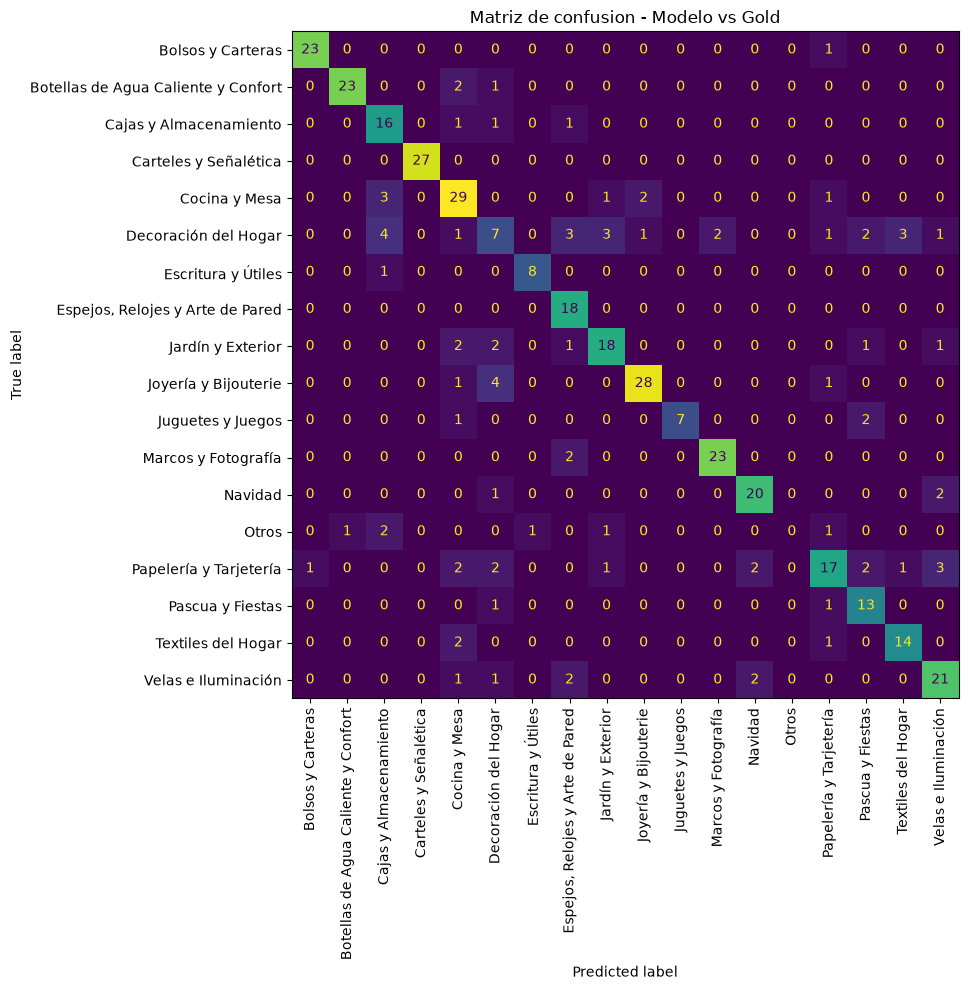

In [43]:
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_gold, y_pred, xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Matriz de confusion - Modelo vs Gold")
plt.tight_layout()
plt.show()

**Observación:** Luego de varias iteraciones de ajustes sobre el modelo, ya sea por cambios de reglas categoricas, ampliación de taxonomia, o correcciones en la muestra gold, llegamos a un resultado positivo del modelo, el cual supera la baseline por 3,5 puntos (78,0% vs. 74,5%) contra la muestra gold, por tanto, podemos asumir que este modelo es util para predecir.

## 7. Inferencia sobre el catálogo completo

### 7.1 Predecir categoría + Margen de confianza

In [44]:
import numpy as np

X_todo = catalogo["description_clean"]

catalogo["categoria_predicha"] = modelo_final.predict(X_todo)

scores = modelo_final.decision_function(X_todo)
scores_ordenados = np.sort(scores, axis=1)
catalogo["confianza_margen"] = scores_ordenados[:, -1] - scores_ordenados[:, -2]

catalogo["categoria_predicha"].value_counts()

categoria_predicha
Cocina y Mesa                          1060
Velas e Iluminación                     494
Joyería y Bijouterie                    447
Papelería y Tarjetería                  417
Decoración del Hogar                    354
Cajas y Almacenamiento                  260
Navidad                                 255
Bolsos y Carteras                       243
Espejos, Relojes y Arte de Pared        214
Jardín y Exterior                       189
Pascua y Fiestas                        149
Escritura y Útiles                      143
Textiles del Hogar                      132
Juguetes y Juegos                       126
Marcos y Fotografía                      95
Carteles y Señalética                    78
Botellas de Agua Caliente y Confort      68
Name: count, dtype: int64

### 7.2 Revisar las 50 predicciones de menor confianza

In [45]:
baja_confianza = catalogo.sort_values("confianza_margen").head(50)
baja_confianza[["stock_code", "description_clean", "categoria_predicha", "confianza_margen", "revenue_total"]]

,stock_code,description_clean,categoria_predicha,confianza_margen,revenue_total
3526,84313A,PINK TV TRAY TABLE,Cocina y Mesa,0.000171,212.42
102,16248B,BLUE HOLE PUNCH,Cajas y Almacenamiento,0.000197,101.25
1441,22212,FOUR HOOK WHITE LOVEBIRDS,Velas e Iluminación,0.000524,8642.30
1680,22474,SPACEBOY TV DINNER TRAY,Cocina y Mesa,0.000877,4746.53
3104,47503A,ASS FLORAL PRINT MULTI SCREWDRIVER,Bolsos y Carteras,0.001269,1405.51
2946,35980C,REDWHITE STRIPE SCANDINAVIAN HEART,Papelería y Tarjetería,0.001583,147.64
2407,23227,FILIGREE HEART BUTTERFLY WHITE,Cocina y Mesa,0.002072,2070.06
3639,84569D,PACK 6 HEART ICE CREAM PATCHES,Bolsos y Carteras,0.002190,1287.54
978,21657,MILK BOTTLE WITH GLASS STOPPER,Botellas de Agua Caliente y Confort,0.002328,1967.38
3522,84292,ROSE PINK METAL FOLDING CHAIR,Velas e Iluminación,0.002558,385.98


**Observación:** Con la predicción sobre el dataset entero, se revisaron las predicciones con peor margen de confianza, en el cual se puede notar que hay un gran presencia de la categoria "Cocina y mesa", esto ocurre porque esta misma clase es la que tiene más ejemplares en el entrenamiento que se le realizo al modelo.

Con este hecho, el modelo cuando trata de encajar un clase sobre un producto que no tiene ningun peso con ninguna, la clase con más ejemplos de entrenamiento tiende a "ganar los empates" por default, porque su región de decisión en el espacio de features es más amplia simplemente por tener más masa de datos.

Con esto dicho, lo mejor seria aplicar un umbral sobre los margenes de menor confianza para dejarlos "sin categoria" o en "Otros".

In [46]:
scores_gold = modelo_final.decision_function(X_gold_text)
scores_gold_ordenados = np.sort(scores_gold, axis=1)
margen_gold = scores_gold_ordenados[:, -1] - scores_gold_ordenados[:, -2]

acierto_gold = (y_pred == y_gold).values

calibracion = pd.DataFrame({"margen": margen_gold, "acierto": acierto_gold})

for umbral in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]:
    bajo = calibracion[calibracion["margen"] < umbral]
    alto = calibracion[calibracion["margen"] >= umbral]
    acierto_bajo = bajo["acierto"].mean() if len(bajo) else float("nan")
    print(f"umbral={umbral:<5} | margen < umbral: n={len(bajo):3d}, acierto={acierto_bajo:.1%}"
          f"  |  margen >= umbral: n={len(alto):3d}, acierto={alto['acierto'].mean():.1%}")

umbral=0.01  | margen < umbral: n=  0, acierto=nan%  |  margen >= umbral: n=400, acierto=78.0%
umbral=0.05  | margen < umbral: n=  3, acierto=66.7%  |  margen >= umbral: n=397, acierto=78.1%
umbral=0.1   | margen < umbral: n= 13, acierto=15.4%  |  margen >= umbral: n=387, acierto=80.1%
umbral=0.2   | margen < umbral: n= 24, acierto=29.2%  |  margen >= umbral: n=376, acierto=81.1%
umbral=0.3   | margen < umbral: n= 31, acierto=32.3%  |  margen >= umbral: n=369, acierto=81.8%
umbral=0.5   | margen < umbral: n= 46, acierto=32.6%  |  margen >= umbral: n=354, acierto=83.9%


**Observación:** Con el gold ya revisado, el punto de separación más limpio se corrió a 0.1: apenas 13 productos, con 15,4% de acierto — la señal más pura de "no sé". En 0.2 ya hay 24 productos pero el acierto sube a 29,2% (empieza a diluirse), y en 0.3 (31, 32,3%) y 0.5 (46, 32,6%) se acerca cada vez más al promedio general del modelo. El corte en 0.05 (n=3, 66,7%) se descarta por tener muy pocos casos para sacar una conclusión. Se mantiene el umbral en 0.2: es más generoso que el punto más puro (0.1) pero sigue aislando una franja con acierto claramente peor que el 78% promedio del modelo.

### 7.3 Aplicar umbral con fallback a las reglas

In [47]:
UMBRAL_CONFIANZA = 0.2

catalogo["categoria_final"] = np.where(
    catalogo["confianza_margen"] < UMBRAL_CONFIANZA,
    catalogo["categoria_regla"].fillna("Sin clasificar"),
    catalogo["categoria_predicha"],
)

print("Antes del ajuste (categoria_predicha):")
print(catalogo["categoria_predicha"].value_counts(normalize=True).head(3))
print("\nDespues del ajuste (categoria_final):")
print(catalogo["categoria_final"].value_counts(normalize=True).head(3))
print(f"\nProductos 'Sin clasificar': {(catalogo['categoria_final'] == 'Sin clasificar').sum()}")

Antes del ajuste (categoria_predicha):
categoria_predicha
Cocina y Mesa           0.224386
Velas e Iluminación     0.104572
Joyería y Bijouterie    0.094623
Name: proportion, dtype: float64

Despues del ajuste (categoria_final):
categoria_final
Cocina y Mesa          0.17337
Sin clasificar         0.15199
Velas e Iluminación    0.09547
Name: proportion, dtype: float64

Productos 'Sin clasificar': 718


#### Validación (estrategia híbrida vs gold)

In [48]:
categoria_regla_gold = gold_labels.merge(
    catalogo[["stock_code", "categoria_regla"]], on="stock_code", how="left"
)["categoria_regla"]

categoria_final_gold = np.where(
    margen_gold < UMBRAL_CONFIANZA,
    categoria_regla_gold.fillna("Sin clasificar"),
    y_pred,
)

accuracy_hibrido = (categoria_final_gold == y_gold).mean()
print(f"Accuracy solo modelo (umbral 0)            : {accuracy_modelo:.1%}")
print(f"Accuracy con fallback a reglas (umbral 0.2): {accuracy_hibrido:.1%}")

Accuracy solo modelo (umbral 0)            : 78.0%
Accuracy con fallback a reglas (umbral 0.2): 77.2%


**Observación:** La comparación termina siendo prácticamente un empate, con una diferencia de 0,8 puntos de Accuracy entre una estrategia y la otra (78,0% solo modelo vs. 77,2% con fallback a reglas), aunque esto no muestra la imagen completa de lo que se queria hacer del todo con la aplicación de umbral.

El objetivo del umbral no era subir el accuracy general, era corregir el sesgo sistemático hacia "Cocina y Mesa" que encontramos en el top-50 (bandejas de TV, estanterías metálicas, sillas plegables, todos "adivinados" como cocina por ser la clase más grande). Ese sesgo no se ve en un accuracy promedio de 400 productos randoms, se ve en que la participación de Cocina bajó de 22,4% a 17,3%.

Por lo tanto, es una decisión concreta dejar el umbral aplicado en el catalogo con un mayor porcentaje de "Sin clasificar", esto es preferible respecto a dejar productos mal clasificados escondidos en otras clasificaciones, generando ruido o imprecisión estructural.

### 7.4 Guardar el catálogo categorizado

In [49]:
catalogo.to_csv("data/processed/products_categorized.csv", index=False)